# Hasil Analisis Trek SEM APME 2025 — untuk Vehicle Dynamics
### Peta Trek, Radius Tikungan, dan Sudut Elevasi

---

Notebook ini hanya menampilkan **hasil** analisis — tidak ada kode algoritma di sini. Tinggal jalankan tiap cell dari atas ke bawah (Cell → Run All).

Kalau butuh lihat bagaimana angka-angka ini dihitung (metodologi), lihat `SEM_APME2025_Track_Analysis.ipynb`.

> **Catatan penting:** Turn 2 dan Turn 6 di tabel di bawah adalah tikungan resmi, tapi radiusnya sangat lebar (>300m) dan sangat landai — **tidak signifikan untuk perhitungan kecepatan menikung atau desain steering**. Bisa diabaikan/tidak perlu jadi prioritas saat mendesain berdasarkan data ini.

---

In [1]:
import pandas as pd
from IPython.display import Image, display

DATA_DIR   = '../data'
ASSETS_DIR = '../assets'
CSV_FILE   = f'{DATA_DIR}/track_analysis_final.csv'

print('Siap. Data akan dimuat dari:', CSV_FILE)

Siap. Data akan dimuat dari: ../data/track_analysis_final.csv


## 1. Peta Trek (Track Map)

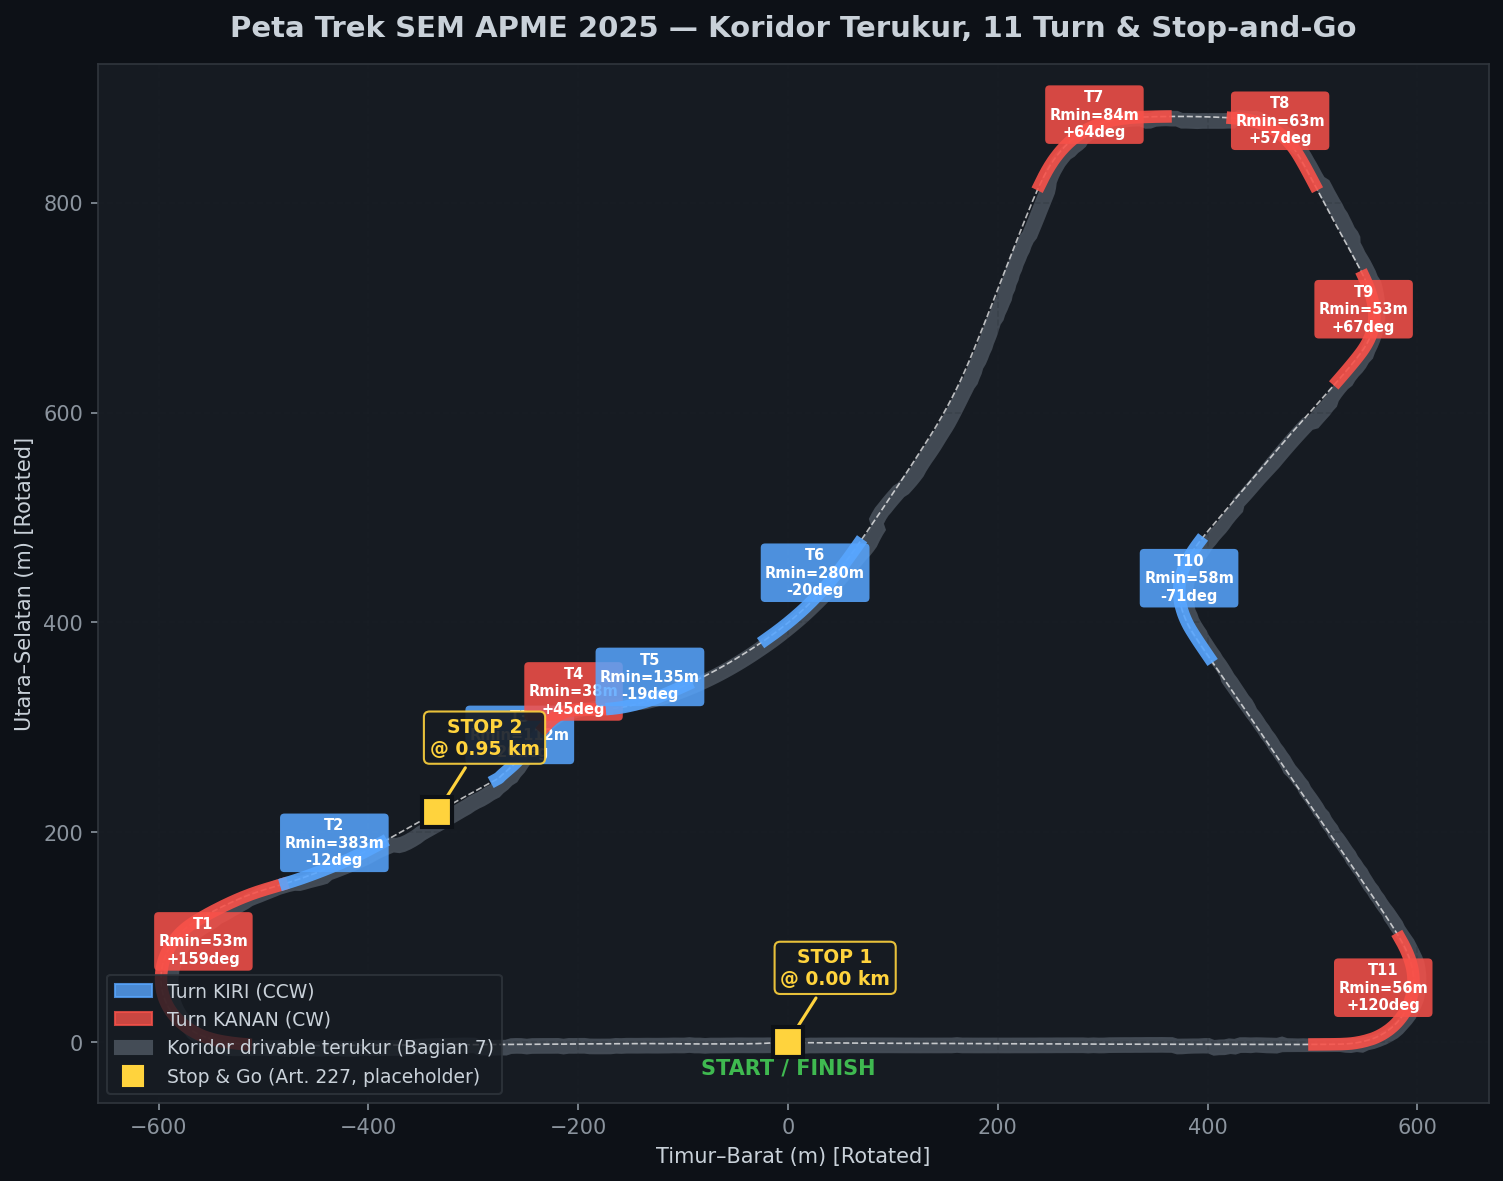

In [2]:
display(Image(filename=f'{ASSETS_DIR}/plot_peta_trek.png'))

## 2. Radius Tikungan (Turning Radius) per Turn

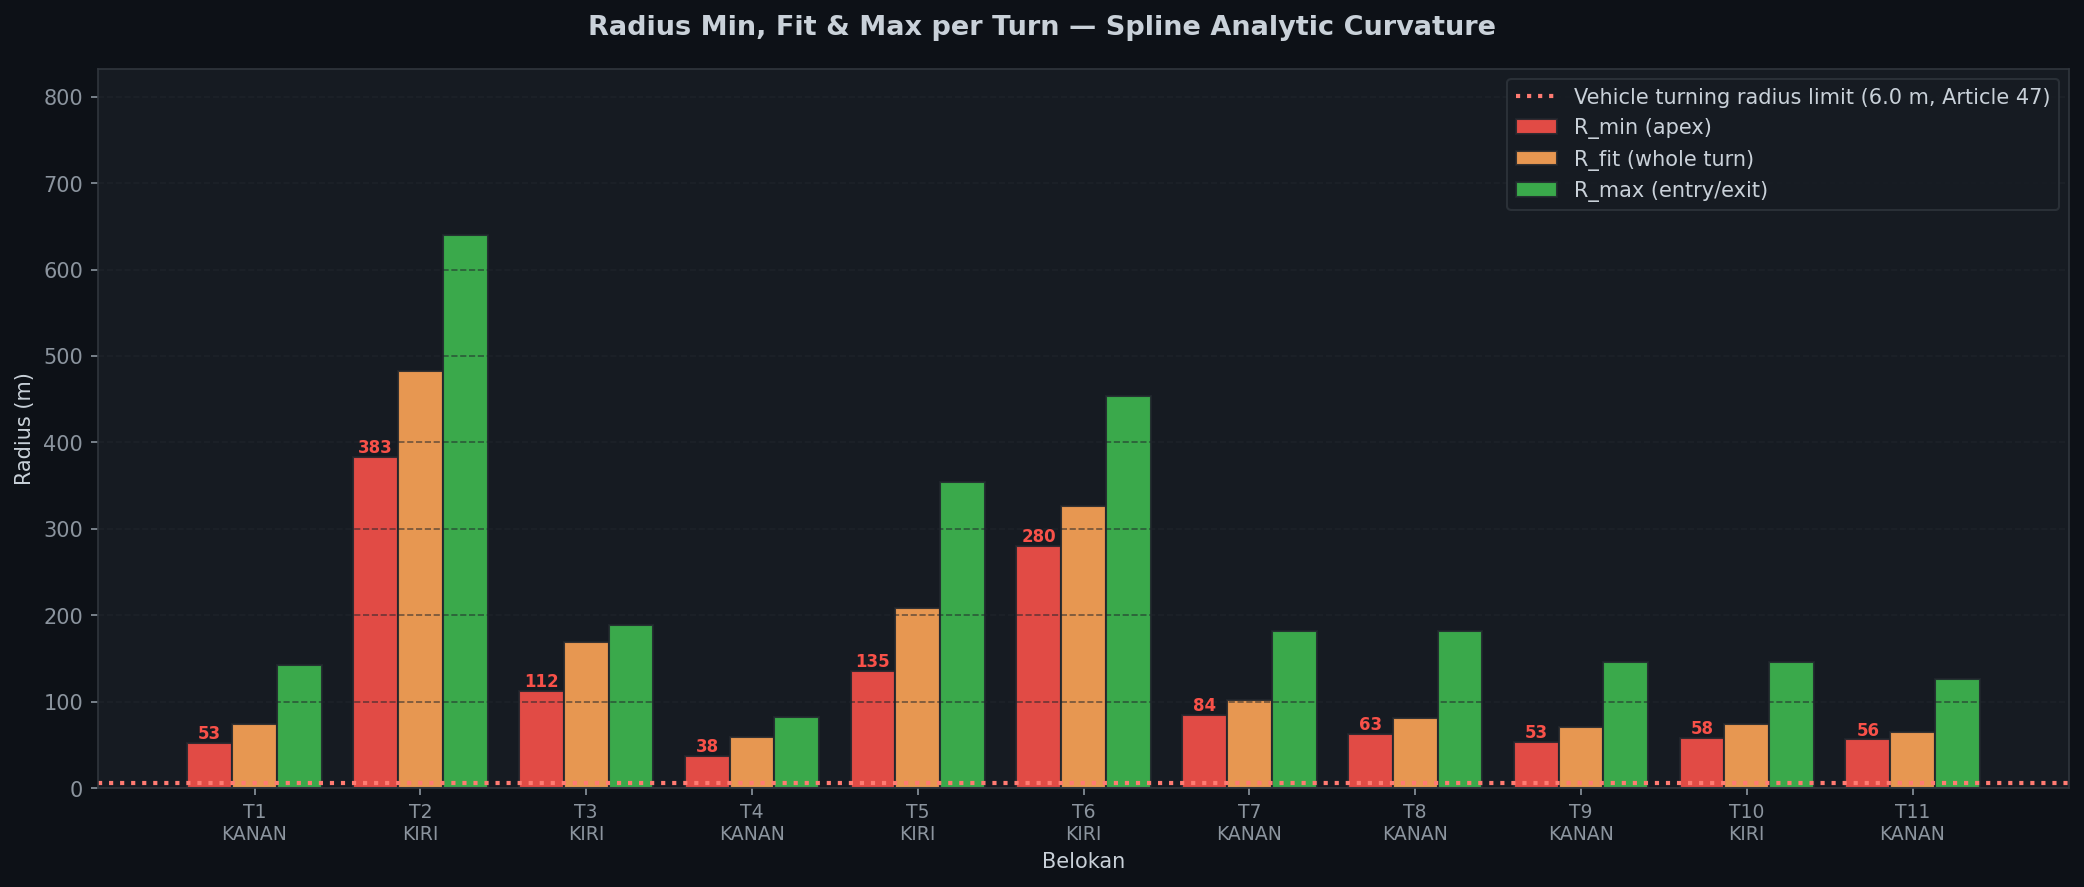

In [3]:
display(Image(filename=f'{ASSETS_DIR}/plot_radius_per_turn.png'))

### Tabel Radius Tikungan

In [4]:
turns = pd.read_csv(CSV_FILE, skiprows=29, nrows=11)

turns_clean = turns.rename(columns={
    'No': 'Turn',
    'Dist Start (km)': 'Mulai (km)',
    'Dist End (km)': 'Selesai (km)',
    'Sudut Kumulatif (deg)': 'Sudut (deg)',
    'R_min (m) [APEX - titik paling ketat]': 'R_min (m)',
    'R_max (m) [ENTRY/EXIT]': 'R_max (m)',
    'V aman di R_min (km/h, mu=0.85)': 'V Aman (km/h)',
})[['Turn', 'Mulai (km)', 'Selesai (km)', 'Arah', 'Sudut (deg)',
    'R_min (m)', 'R_max (m)', 'Confidence', 'V Aman (km/h)']]

turns_clean['Catatan'] = ''
turns_clean.loc[turns_clean['Turn'].isin([2, 6]), 'Catatan'] = 'Minor — radius lebar, tidak kritis'

turns_clean

,Turn,Mulai (km),Selesai (km),Arah,Sudut (deg),R_min (m),R_max (m),Confidence,V Aman (km/h),Catatan
0,1,0.517,0.786,KANAN (CW),159.00,52.7,141.9,High,75.5,
1,2,0.791,0.889,KIRI (CCW),-11.81,383.0,640.5,Medium,203.5,"Minor — radius lebar, tidak kritis"
2,3,1.015,1.077,KIRI (CCW),-20.05,111.9,188.6,Low,110.0,
3,4,1.083,1.147,KANAN (CW),44.96,37.6,82.4,Medium,63.7,
4,5,1.153,1.227,KIRI (CCW),-19.07,135.4,353.9,Medium,121.0,
5,6,1.315,1.442,KIRI (CCW),-20.22,280.5,453.3,Medium,174.1,"Minor — radius lebar, tidak kritis"
6,7,1.829,1.975,KANAN (CW),64.11,84.4,181.8,Medium,95.5,
7,8,2.040,2.146,KANAN (CW),57.48,62.9,182.2,Medium,82.4,
8,9,2.246,2.357,KANAN (CW),66.68,53.2,146.0,Medium,75.9,
9,10,2.561,2.682,KIRI (CCW),-71.25,57.9,145.6,Medium,79.1,


**Cara baca tabel:**
- **R_min** = radius paling ketat di tikungan itu (titik apex) — ini yang menentukan batas kecepatan aman.
- **R_max** = radius di bagian entry/exit tikungan (lebih lebar dari apex).
- **V Aman** = kecepatan maksimum yang aman di R_min, asumsi koefisien gesek ban (mu) = 0.85.
- **Confidence** = seberapa stabil angka R_min ini (High/Medium/Low). Kalau Low, sebaiknya jangan dijadikan patokan tanpa dicek manual dulu.
- Tikungan paling kritis (radius tersempit) di trek ini: **Turn 4, R_min ≈ 37.6 m**.

## 3. Sudut Elevasi (Elevation Angle)

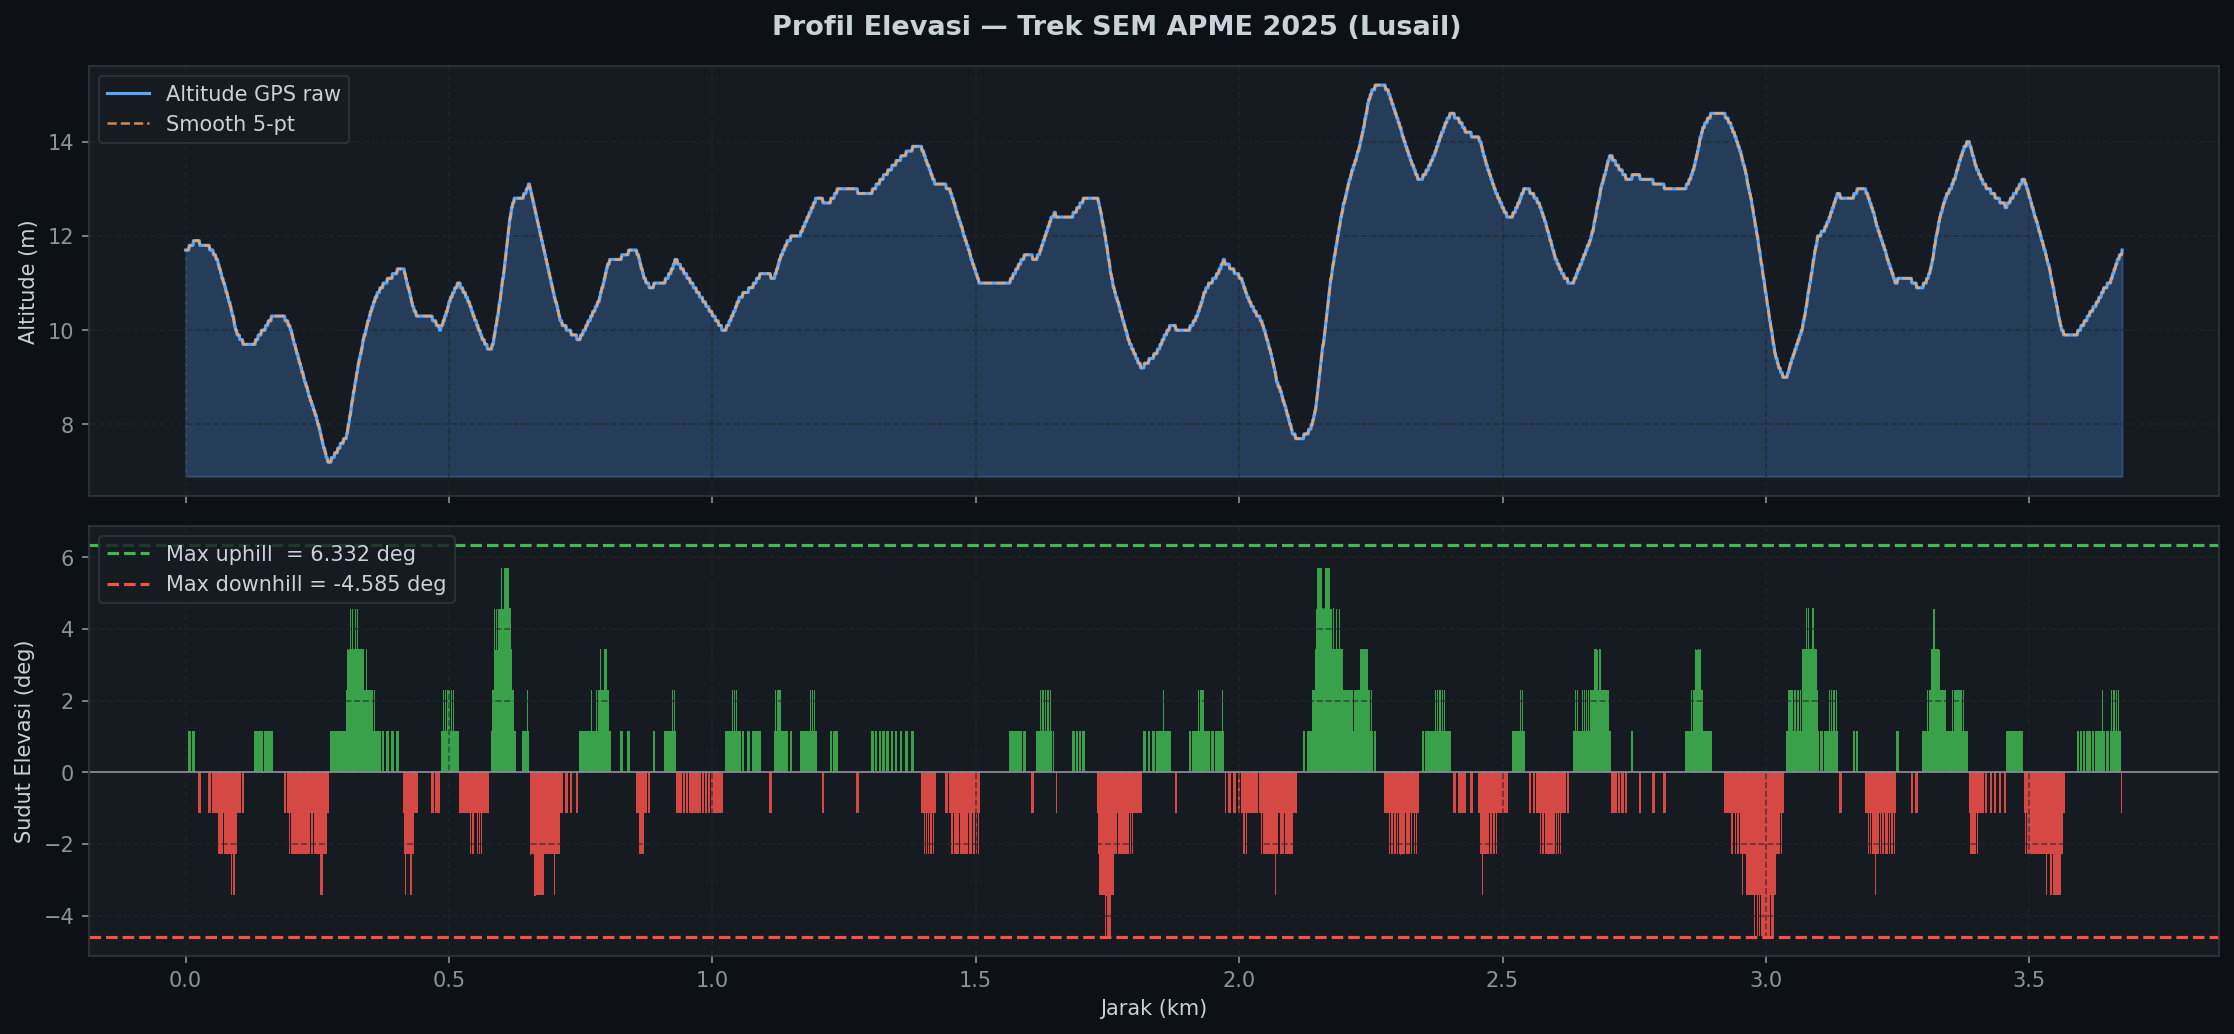

In [5]:
display(Image(filename=f'{ASSETS_DIR}/plot_elevasi.png'))

### Ringkasan Sudut Elevasi

In [6]:
elev = pd.read_csv(CSV_FILE, skiprows=19, nrows=2)
elev

,Parameter,Sudut (deg),Grade (%),Lokasi (km),Confidence
0,Max Uphill,5.5381,9.70,0.602,High
1,Max Downhill,-4.4292,-7.75,2.997,High


## Catatan Penting

1. **Turn 2 dan Turn 6**: tikungan resmi tapi radius sangat lebar (>300m), landai — tidak signifikan untuk desain steering atau batas kecepatan menikung. Tidak perlu jadi prioritas perhitungan.

2. **Sumber data**: file koordinat GPS asli (`sem_apme_2025-track_coordinates.csv` dan `sem_apme_2025.kml`) disediakan Shell Eco-marathon **untuk keperluan riset saja** — bukan data survey resmi bersertifikat. Angka di atas adalah estimasi terbaik dari data tersebut, bukan spesifikasi teknik yang pasti. Pakai sebagai input perencanaan (planning), beri margin keamanan untuk keputusan desain akhir.

3. **Data mentah tersedia**: kalau perlu hitung ulang sudut elevasi atau radius sendiri, file mentahnya ada di folder `/data`:
   - `sem_apme_2025-track_coordinates.csv` — trek di-resample rapi ke jarak ~1m per titik.
   - `sem_apme_2025.kml` — GPS fix asli (spacing tidak beraturan, presisi altitude lebih tinggi) — ini yang dipakai untuk hasil final di atas.

4. **Full CSV hasil analisis** (semua kolom detail, termasuk cross-check dan metode lama untuk perbandingan): `track_analysis_final.csv` di folder `/data`.